# Headers

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from typing import List, Union, Tuple

import sys
import os
import io
from contextlib import redirect_stdout, redirect_stderr


import pickle

import comet_ml
import json


try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()
    
parent_dir = os.path.join(current_dir, '..', '..')
sys.path.insert(0, parent_dir)
    
    
from analysis_scripts.config import CFG
from analysis_scripts.estimate_scripts import get_mass_distributions
from analysis_scripts.draw_scripts import total_spectrum
from analysis_scripts.draw_scripts import tssa_area_plot
from analysis_scripts.draw_scripts import tssa_error_plot
from analysis_scripts.estimate_scripts import calculate_sb_ratio_2gauss_pol2
from analysis_scripts.fit_scripts import fit_distr_double_gauss_and_pol2
from analysis_scripts.estimate_scripts import calculate_tssa_sig_errors_local


CFG.seed_all(CFG.seed)
sns.set_theme(style='ticks')

CUDA available: False
Use CPU, 
Number of CPUs: 12


/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/analysis_notebooks/supporting analysis/../../analysis_scripts/fit_scripts.py:310: SyntaxWarning: invalid escape sequence '\m'
  unit_name: str = '$\mu m$') -> Tuple:
/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/analysis_notebooks/supporting analysis/../../analysis_scripts/fit_scripts.py:767: SyntaxWarning: invalid escape sequence '\m'
  unit_name: str = '$\mu m$') -> Tuple:
/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/analysis_notebooks/supporting analysis/../../analysis_scripts/fit_scripts.py:1561: SyntaxWarning: invalid escape sequence '\m'
  unit_name: str = '$\mu m$'
/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/analysis_notebooks/supporting analysis/../../analysis_scripts/fit_scripts.py:2291: SyntaxWarning: invalid escape sequence '\m'
  unit_name: str = '$\mu m$') -> Tuple:


# Load Data

In [2]:
data_oc_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_signal_1_new.csv')
data_mb_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_background_1_new.csv')

data_oc_df = data_oc_df.drop(['n_event'], axis=1)

mass_mask = (data_oc_df['true_decay'] == 1)
                
data_oc_df = data_oc_df[mass_mask]
data_oc_df['tag'] = 'Sig'

data_mb_df = data_mb_df.drop(['n_event'], axis=1)

data_mb_df['tag'] = 'Bg'

raw_df = pd.concat([data_oc_df, data_mb_df], axis=0).reset_index(drop=True)

raw_df['cosAngle_r_Lc_momentum_Lc_xy'] = raw_df['cosAngle_r_Lc_momentum_Lc_xy'].apply(np.cos)
raw_df['cosAngle_r_Lc_sum_momentum_xy'] = raw_df['cosAngle_r_Lc_sum_momentum_xy'].apply(np.cos)
raw_df['cosAngle_momentum_Lc_sum_momentum_xy'] = raw_df['cosAngle_momentum_Lc_sum_momentum_xy'].apply(np.cos)


xf_and_pt_data = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/xF_annd_Pt_Lc_data_after_ML.csv')
xf_and_pt_data = xf_and_pt_data.drop(columns='Unnamed: 0', axis=1)

array([[<Axes: title={'center': 'xF'}>,
        <Axes: title={'center': 'Pt_Lc'}>]], dtype=object)

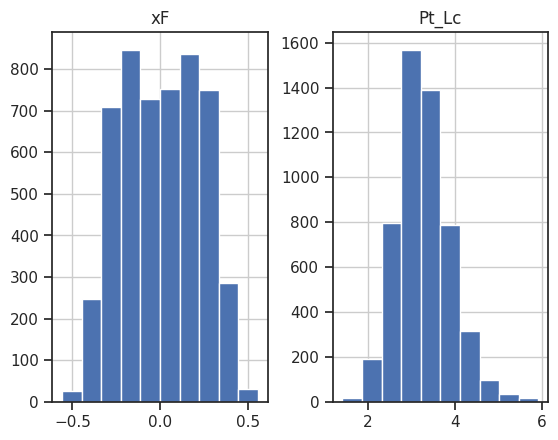

In [3]:
xf_and_pt_data.hist()

In [4]:
with open("/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/preselection_mask_train_pickle.pkl", "rb") as f:
    preselection_mask = pickle.load(f)

proc_df = raw_df.query(preselection_mask).reset_index(drop=True)

# TSSA areas plots

In [5]:
# with open("/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/combined_fit_ML_wide_2gauss_pol2.pkl", "rb") as f:
#     fit_result = pickle.load(f)

In [6]:
# mean = 2.2856

# min_raw = 2.18 (mean - 11.55 small sigma) (mean - 4.50 small sigma)
# max_raw = 2.4 (mean + 12.36 small sigma) (mean + 4.82 big sigma)

# sigma MC = 0.0092 (mass_interval(2.24763, 2.32497) = +-4.2 sigma)
# sigma CF = 0.023 (mass_interval(2.24763, 2.32497) = +-1.6 sigma)



# right peak = 2.301 (+-1.5 sigma small)
# left peak = 2.2725 

# right left bg = 2.3139 (3 sigma small)
# right right bg = 2.3231 (4 sigma small)

# left right bg = 2.2587 (3 sigma small)
# left left bg = 2.2495 (4 sigma small)



# right peak = 2.3201 (+-1.5 sigma big)
# left peak = 2.2511

# right left bg = 2.3546 (3 sigma big)
# right right bg = 2.3776 (4 sigma big) or max

# left right bg = 2.2166 (3 sigma big)
# left left bg = 2.1936 (4 sigma big) or min

<Axes: >

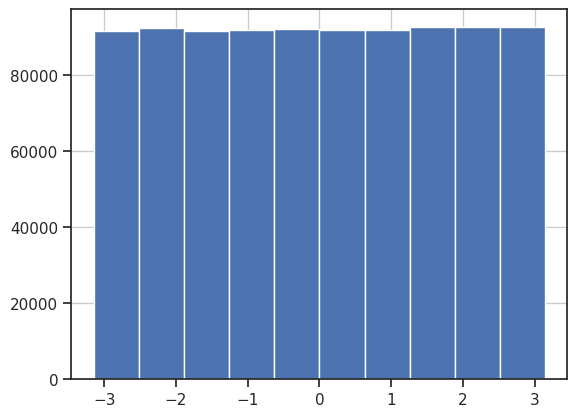

In [7]:
proc_df['phi_angle'].hist()

# TSSA Calculation

In [8]:
def get_part_of_events_in_range(
    feature_range: Union[List, Tuple],
    distr: pd.Series,
    is_abs: bool
):
    counts_all = distr.count()
    
    if is_abs:
        counts_in = distr[(feature_range[0] <= np.abs(distr)) & (np.abs(distr) <= feature_range[1])].count()
    else:
        counts_in = distr[(feature_range[0] <= distr) & (distr <= feature_range[1])].count()
    
    return counts_in / counts_all

### xF Gaps

Method: Nelder-Mead
Method: Powell
****************************************************************************************************
New best method: Powell, success: True
****************************************************************************************************
Method: CG
Method: BFGS
Method: Newton-CG
Method: L-BFGS-B
Method: TNC
Method: COBYLA
Method: COBYQA
Method: SLSQP
Skip method: SLSQP
Method: trust-constr
****************************************************************************************************
New best method: trust-constr, success: True
****************************************************************************************************
Method: dogleg
Method: trust-ncg
Method: trust-exact
Method: trust-krylov
********************************************************************************
********************************************************************************
********************************************************************************
best_

/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/analysis_notebooks/supporting analysis/../../analysis_scripts/draw_scripts.py:675: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r:" (-> linestyle=':'). The keyword argument will take precedence.
  ax.plot(x_bins, g1 + g2 + pol2, 'r:', label=total_label, linestyle='-', linewidth=3, alpha=0.7)


Method: Nelder-Mead
Method: Powell
****************************************************************************************************
New best method: Powell, success: True
****************************************************************************************************
Method: CG
Method: BFGS
Method: Newton-CG
Method: L-BFGS-B
Method: TNC
Method: COBYLA
Method: COBYQA
Method: SLSQP
Skip method: SLSQP
Method: trust-constr
****************************************************************************************************
New best method: trust-constr, success: True
****************************************************************************************************
Method: dogleg
Method: trust-ncg
Method: trust-exact
Method: trust-krylov
********************************************************************************
********************************************************************************
********************************************************************************
best_

/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/analysis_notebooks/supporting analysis/../../analysis_scripts/draw_scripts.py:675: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r:" (-> linestyle=':'). The keyword argument will take precedence.
  ax.plot(x_bins, g1 + g2 + pol2, 'r:', label=total_label, linestyle='-', linewidth=3, alpha=0.7)


Method: Nelder-Mead
Method: Powell
****************************************************************************************************
New best method: Powell, success: True
****************************************************************************************************
Method: CG
Method: BFGS
Method: Newton-CG
Method: L-BFGS-B
Method: TNC
Method: COBYLA
Method: COBYQA
Method: SLSQP
Skip method: SLSQP
Method: trust-constr
Method: dogleg
Method: trust-ncg
Method: trust-exact
Method: trust-krylov
********************************************************************************
********************************************************************************
********************************************************************************
best_method='Powell'
Optimization result:
Success: True
Message: Optimization terminated successfully.
Number of iterations: 9
Final objective value: 735.307509
Chi-squared: 735.31
Reduced chi-squared: 2.664
--------------------------------------------

/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/analysis_notebooks/supporting analysis/../../analysis_scripts/fit_scripts.py:1634: OptimizeWarning: Initial guess is not within the specified bounds
  result = minimize(
/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/analysis_notebooks/supporting analysis/../../analysis_scripts/draw_scripts.py:675: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r:" (-> linestyle=':'). The keyword argument will take precedence.
  ax.plot(x_bins, g1 + g2 + pol2, 'r:', label=total_label, linestyle='-', linewidth=3, alpha=0.7)


Method: Nelder-Mead
Method: Powell
****************************************************************************************************
New best method: Powell, success: True
****************************************************************************************************
Method: CG
Method: BFGS
Method: Newton-CG
Method: L-BFGS-B
****************************************************************************************************
New best method: L-BFGS-B, success: True
****************************************************************************************************
Method: TNC
Method: COBYLA
Method: COBYQA
Method: SLSQP
Skip method: SLSQP
Method: trust-constr
Method: dogleg
Method: trust-ncg
Method: trust-exact
Method: trust-krylov
********************************************************************************
********************************************************************************
********************************************************************************
best_meth

/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/analysis_notebooks/supporting analysis/../../analysis_scripts/draw_scripts.py:675: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r:" (-> linestyle=':'). The keyword argument will take precedence.
  ax.plot(x_bins, g1 + g2 + pol2, 'r:', label=total_label, linestyle='-', linewidth=3, alpha=0.7)


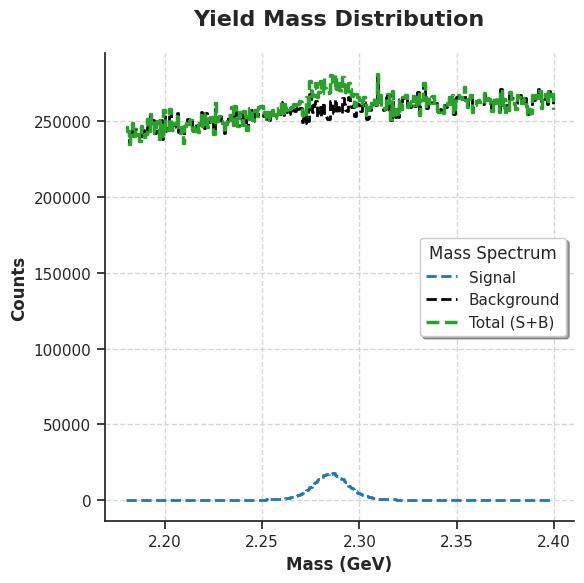

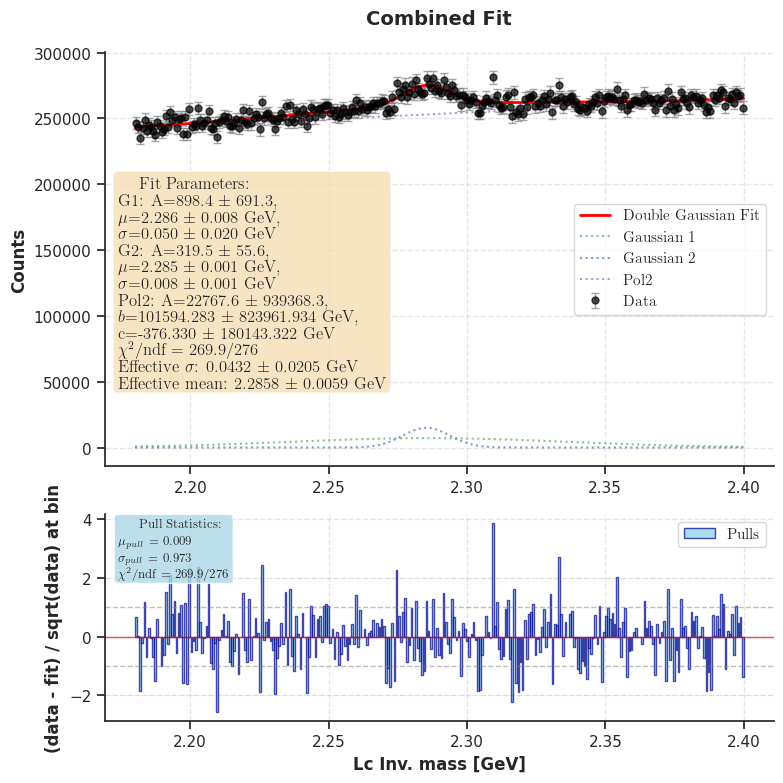

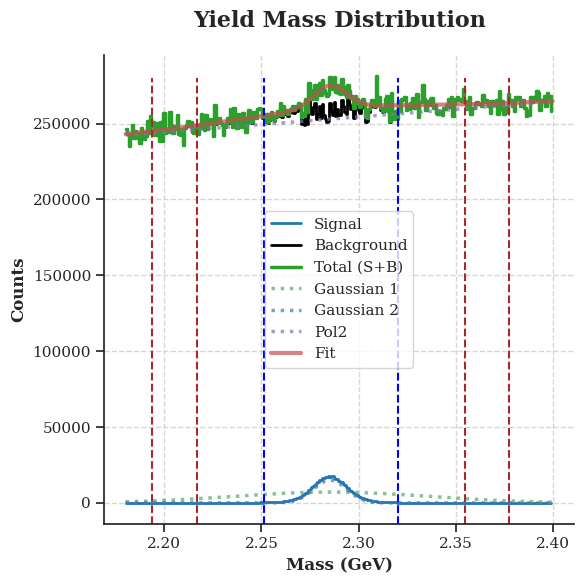

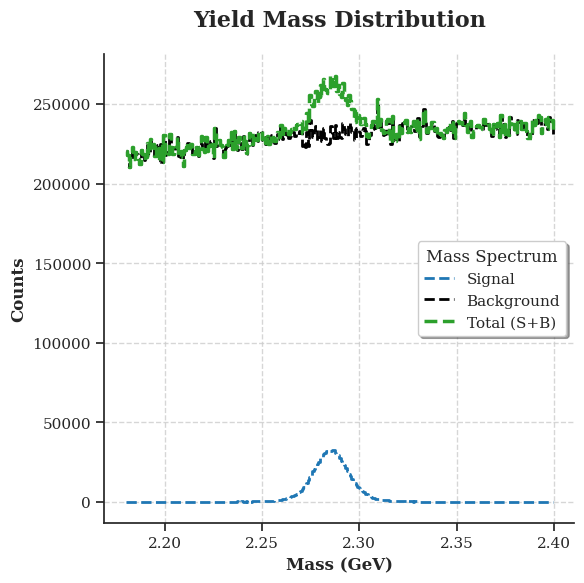

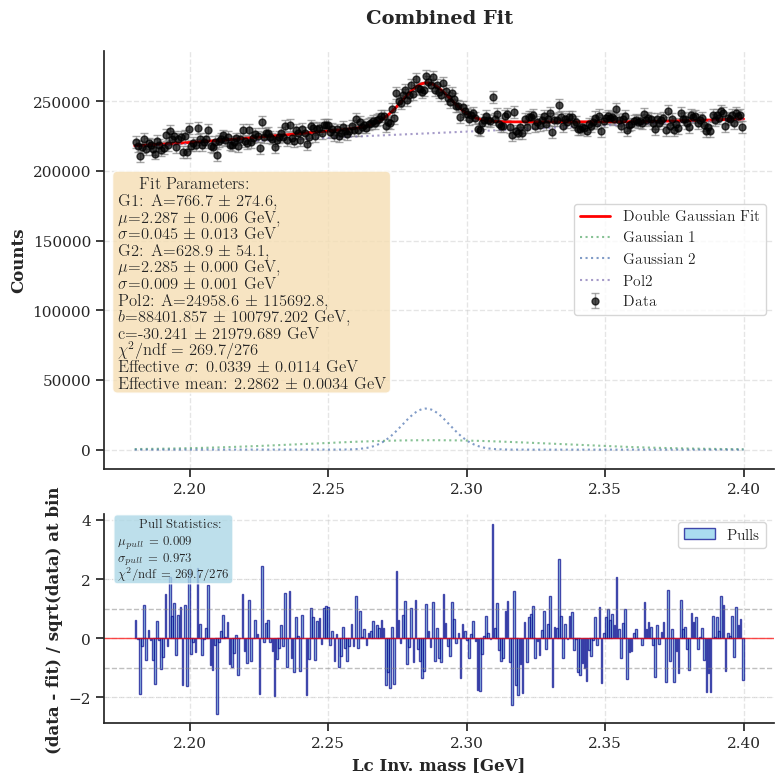

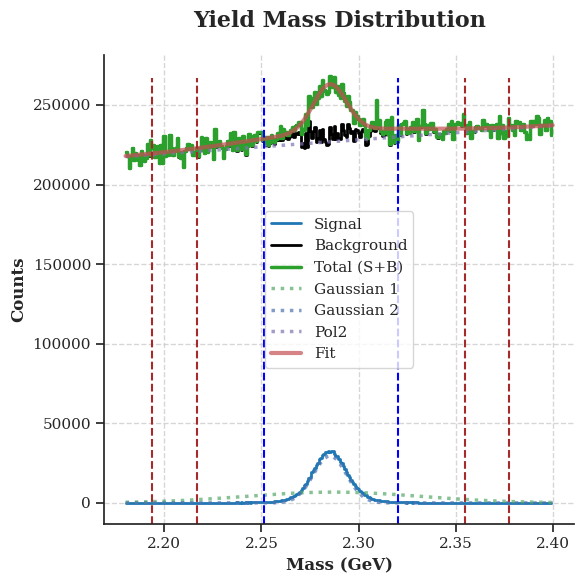

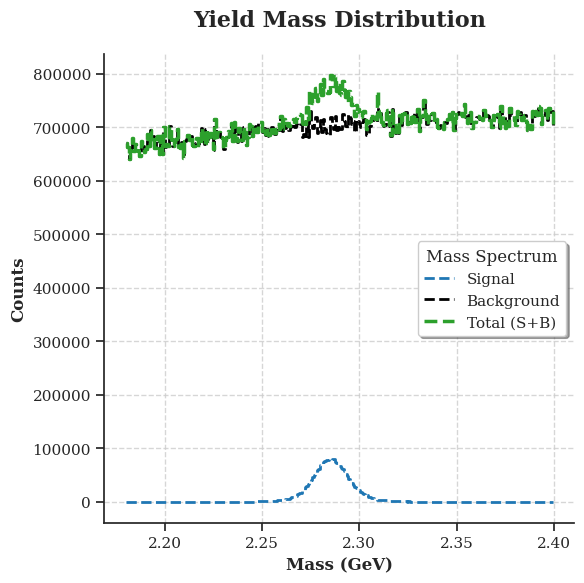

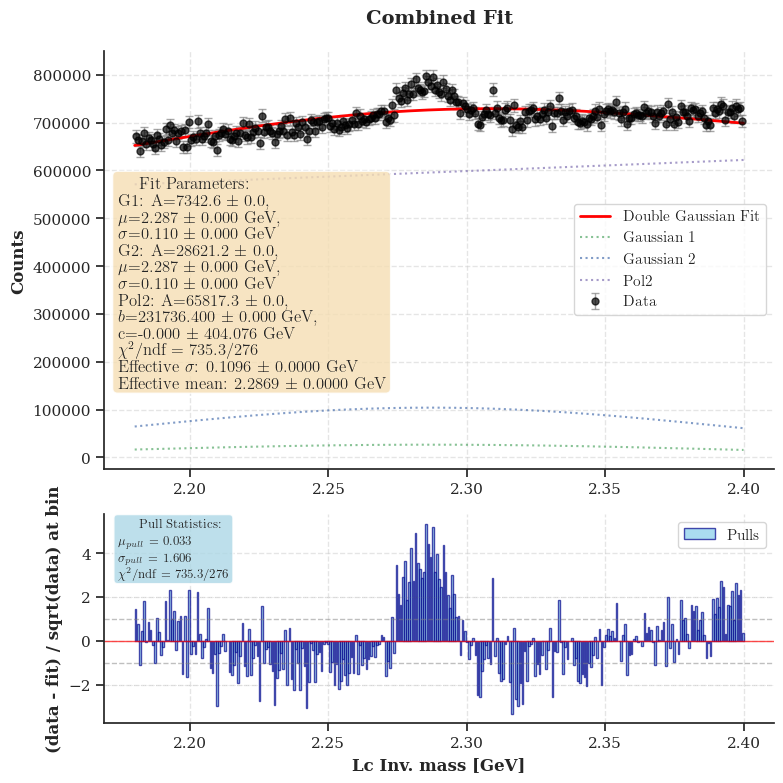

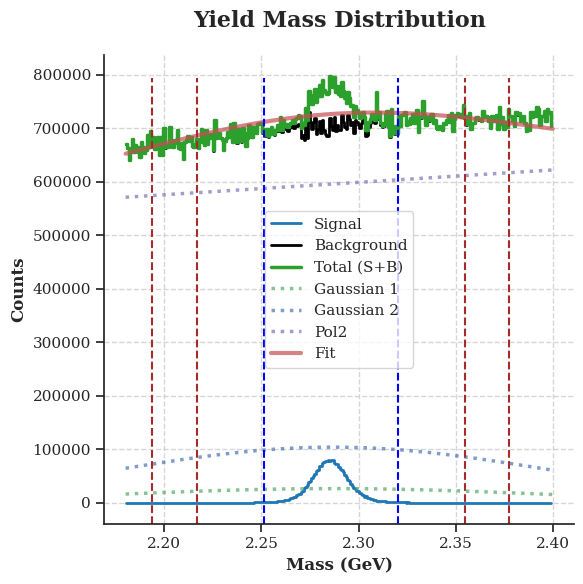

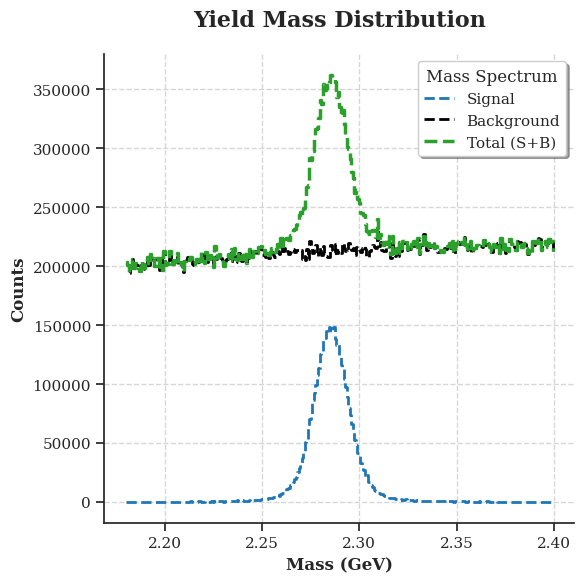

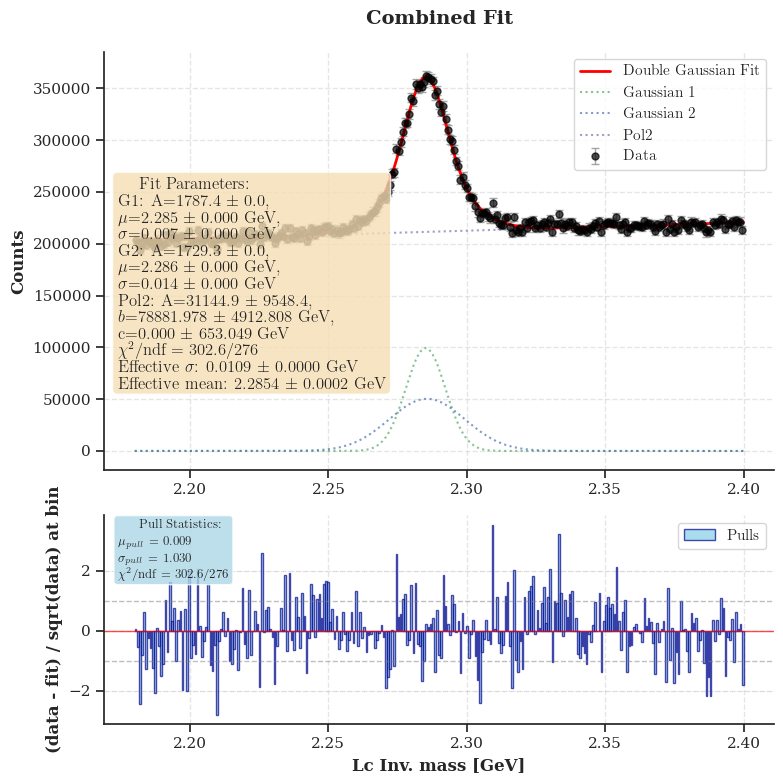

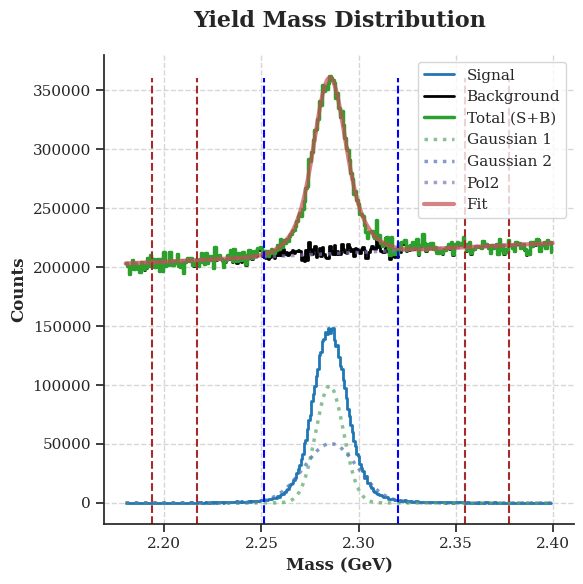

In [9]:
phi_gaps = [(0., np.pi / 6), (np.pi / 6, np.pi * 2 / 6), (np.pi * 2 / 6, np.pi * 3 / 6), (np.pi * 3 / 6, np.pi * 4 / 6), (np.pi * 4 / 6, np.pi * 5 / 6), (np.pi * 5 / 6, np.pi)]
gaps = [(0., 0.1), (0.1, 0.2), (0.2, 0.3), (0.3, 1.)]
sig_eff_list=[np.float64(0.026391785656987004), np.float64(0.04897959183673469), np.float64(0.12041454186543839), np.float64(0.22129783693843594)]
bg_eff_list=[np.float64(2.9373320213250306e-05), np.float64(2.6296067423116874e-05), np.float64(8.00298778210532e-05), np.float64(2.4249478636209322e-05)]
is_abs = True

tssa_errors_list = []

for index, gap in enumerate(gaps):

    sig_eff = sig_eff_list[index]
    bg_eff = bg_eff_list[index]

    sig_mass_distr = proc_df.loc[proc_df['tag'] == 'Sig', 'mass_Lc']
    bg_mass_distr = proc_df.loc[proc_df['tag'] == 'Bg', 'mass_Lc']

    proc_mass_min = proc_df.loc[raw_df['tag'] == 'Bg', 'mass_Lc'].min()
    proc_mass_max = proc_df.loc[raw_df['tag'] == 'Bg', 'mass_Lc'].max()
    
    ########################################################################################################
    # Spectrum Plot
    ########################################################################################################
    total_spectrum(
        sig_mass_distr=sig_mass_distr, 
        bg_mass_distr=bg_mass_distr, 
        have_sig_events=CFG.have_sig_events_1 / sig_eff, 
        have_bg_events=CFG.have_bg_events_1 / bg_eff,
        mass_interval=(proc_mass_min, proc_mass_max),
        gev_per_bin=0.000773,
        log_y=False,
        only_total=False,
        line_style='--'
    )

    ########################################################################################################
    # Prepare Fit Distribution
    ########################################################################################################
    total_heights, total_heights_errors, sig_heights, sig_heights_errors, bg_heights, bg_heights_errors, bin_edges, bin_centers = get_mass_distributions(
        sig_mass_distr=sig_mass_distr, 
        bg_mass_distr=bg_mass_distr, 
        have_sig_events=CFG.have_sig_events_1 / sig_eff, 
        have_bg_events=CFG.have_bg_events_1 / bg_eff,
        mass_interval=(proc_mass_min, proc_mass_max),
        gev_per_bin=0.000773
    )

    ########################################################################################################
    # Fit in Gap
    ########################################################################################################
    distr_name='total_mass'

    methods = ['Nelder-Mead', 'Powell', 'CG', 'BFGS', 'Newton-CG', 'L-BFGS-B',
            'TNC', 'COBYLA', 'COBYQA', 'SLSQP', 'trust-constr', 'dogleg',
            'trust-ncg', 'trust-exact', 'trust-krylov']

    min_loss = 1e6
    best_method = None

    for method in methods:

        print(f'Method: {method}')

        if method in ('SLSQP'):
            print(f'Skip method: {method}')
            continue

        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            try:
                fit_res = fit_distr_double_gauss_and_pol2(
                    counts=total_heights,
                    errors=total_heights_errors,
                    bin_centers=bin_centers,
                    bin_edges=bin_edges,
                    title=distr_name,
                    x_label=distr_name + ' [cm]',
                    optimize_method=method,
                    plot=False,
                    max_iter=1000,
                    scaler=1,
                    unit_name='GeV'
                )
            except:
                print(f'Skip method: {method}') 
                continue
        
        result = fit_res['result']
        
        if result['success'] and result['fun'] < min_loss:
            print('*'*100)
            print(f'New best method: {method}, success: {result['success']}')
            print('*'*100)
            best_method = method
            min_loss = result['fun']
        
    print('*' * 80)
    print('*' * 80)
    print('*' * 80)
    print(f'{best_method=}')

    if best_method is None:
        raise ValueError('No successful fit')

    fit_result = fit_distr_double_gauss_and_pol2(
        counts=total_heights,
        errors=total_heights_errors,
        bin_centers=bin_centers,
        bin_edges=bin_edges,
        title='Combined Fit',
        x_label='Lc Inv. mass [GeV]',
        optimize_method=best_method,
        plot=True,
        max_iter=1000,
        scaler=1,
        unit_name='GeV',
        log_y=False,
    )

    # plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/combined_fit_ML_wide_2gauss_pol2.pdf')
    
    ########################################################################################################
    # Calculate Fit Integrals
    ########################################################################################################
    mean = 2.2856
    sigma = 0.023

    borders_pos = [
    mean - 4 * sigma,
    mean - 3 * sigma,
    mean - 1.5 * sigma,
    mean + 1.5 * sigma,
    mean + 3 * sigma,
    mean + 4 * sigma
    ]

    tssa_area_plot(
        sig_mass_distr=sig_mass_distr, 
        bg_mass_distr=bg_mass_distr, 
        have_sig_events=CFG.have_sig_events_1,
        have_bg_events=CFG.have_bg_events_1,
        borders_pos=borders_pos,
        fit_params=fit_result[0]['params'],
        sig_eff=sig_eff,
        bg_eff=bg_eff,
        mass_interval=(proc_mass_min, proc_mass_max),
        gev_per_bin=0.000773,  # (2.32497 - 2.24763) / 100
        log_y=False,
        total=True,
        only_total=False,
        line_style='-'
        )

    # plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/TSSA_areas_plot.pdf')
    
    events_in_area = {
        'left': {'pos_1': borders_pos[0], 'pos_2': borders_pos[1], 'Sig': 0, 'Bg': 0, 'Sig_err': 0, 'Bg_err': 0},
        'peak': {'pos_1': borders_pos[2], 'pos_2': borders_pos[3], 'Sig': 0, 'Bg': 0, 'Sig_err': 0, 'Bg_err': 0},
        'right': {'pos_1': borders_pos[4], 'pos_2': borders_pos[5], 'Sig': 0, 'Bg': 0, 'Sig_err': 0, 'Bg_err': 0}
    }

    for area_pos in events_in_area.keys():
        
        stat_data = calculate_sb_ratio_2gauss_pol2(
            fit_result[0]['params'],
            bin_edges,
            cov_matrix=fit_result[0]['cov_matrix'],
            mass_interval=(events_in_area[area_pos]['pos_1'], events_in_area[area_pos]['pos_2'])
        )    
        
        events_in_area[area_pos]['Sig'] = stat_data['signal']
        events_in_area[area_pos]['Sig_err'] = stat_data['signal_uncertainty']
        events_in_area[area_pos]['Bg'] = stat_data['background']
        events_in_area[area_pos]['Bg_err'] = stat_data['background_uncertainty']

    ########################################################################################################
    # TSSA Calculation
    ########################################################################################################
    tssa_errors_in_phi_gaps = []
    
    for phi_gap in phi_gaps:
    
        distr_part = get_part_of_events_in_range(
            feature_range=gap,
            distr=xf_and_pt_data['xF'],
            is_abs=is_abs
        )

        #################################################
        # peak
                
        # mask = (gap[0] <= np.abs(proc_df['xF'])) & (np.abs(proc_df['xF']) <= gap[1])

        # sig_mass_distr = proc_df.loc[(proc_df['tag'] == 'Sig') & mask, 'mass_Lc']
        # bg_mass_distr = proc_df.loc[(proc_df['tag'] == 'Bg') & mask, 'mass_Lc']
        # 
        # total_heights, total_heights_errors, sig_heights, sig_heights_errors, bg_heights, bg_heights_errors, bin_edges, bin_centers = get_mass_distributions(
        #     sig_mass_distr=sig_mass_distr, 
        #     bg_mass_distr=bg_mass_distr, 
        #     have_sig_events=CFG.have_sig_events_1 / CFG.ML_sig_eff, 
        #     have_bg_events=CFG.have_bg_events_1 / CFG.ML_bg_eff,
        #     mass_interval=(borders_pos[2], borders_pos[3]),
        #     gev_per_bin=0.000773
        # )
    
        # Count
        # N_raw_phi = np.sum(total_heights) / 12 # 12 phi sectors
        # N_raw_phi_pi = np.sum(total_heights) / 12

        # Count
        # N_bg_peak_phi = np.sum(bg_heights) / 12
        # N_bg_peak_phi_pi = np.sum(bg_heights) / 12
    
        # Fit
        N_raw_phi = (events_in_area['peak']['Sig'] + events_in_area['peak']['Bg']) * distr_part / 12
        N_raw_phi_pi = (events_in_area['peak']['Sig'] + events_in_area['peak']['Bg']) * distr_part / 12
    
        # Fit
        N_bg_peak_phi = events_in_area['peak']['Bg'] * distr_part / 12
        N_bg_peak_phi_pi = events_in_area['peak']['Bg'] * distr_part / 12
        
        #################################################
        # side
        
        # Count  
        # total_heights, total_heights_errors, sig_heights, sig_heights_errors, bg_heights, bg_heights_errors, bin_edges, bin_centers = get_mass_distributions(
        #     sig_mass_distr=sig_mass_distr, 
        #     bg_mass_distr=bg_mass_distr, 
        #     have_sig_events=CFG.have_sig_events_1 / CFG.ML_sig_eff, 
        #     have_bg_events=CFG.have_bg_events_1 / CFG.ML_bg_eff,
        #     mass_interval=(borders_pos[0], borders_pos[1]),
        #     gev_per_bin=0.000773
        # )
        # 
        # N_bg_side_phi = np.sum(bg_heights) / 12
        # N_bg_side_phi_pi = np.sum(bg_heights) / 12
        # 
        # total_heights, total_heights_errors, sig_heights, sig_heights_errors, bg_heights, bg_heights_errors, bin_edges, bin_centers = get_mass_distributions(
        #     sig_mass_distr=sig_mass_distr, 
        #     bg_mass_distr=bg_mass_distr, 
        #     have_sig_events=CFG.have_sig_events_1 / CFG.ML_sig_eff, 
        #     have_bg_events=CFG.have_bg_events_1 / CFG.ML_bg_eff,
        #     mass_interval=(borders_pos[4], borders_pos[5]),
        #     gev_per_bin=0.000773
        # )
        # 
        # N_bg_side_phi += np.sum(bg_heights) / 12
        # N_bg_side_phi_pi += np.sum(bg_heights) / 12
        
        # Fit
        N_bg_side_phi = (events_in_area['left']['Bg'] + events_in_area['right']['Bg']) * distr_part / 12
        N_bg_side_phi_pi = (events_in_area['left']['Bg'] + events_in_area['right']['Bg']) * distr_part / 12
        
        # print(f'{N_raw_phi=}')
        # print(f'{N_raw_phi_pi=}')
        # print(f'{N_bg_peak_phi=}')
        # print(f'{N_bg_peak_phi_pi=}')
        # print(f'{N_bg_side_phi=}')
        # print(f'{N_bg_side_phi_pi=}')
        
        tssa_errors_in_phi_gaps.append(calculate_tssa_sig_errors_local(
            N_raw_phi=N_raw_phi,
            N_raw_phi_pi=N_raw_phi_pi,
            N_bg_peak_phi=N_bg_peak_phi,
            N_bg_peak_phi_pi=N_bg_peak_phi_pi,
            N_bg_side_phi=N_bg_side_phi,
            N_bg_side_phi_pi=N_bg_side_phi_pi,
            phi_1=phi_gap[0],
            phi_2=phi_gap[1],
        ))
        
        # print(tssa_errors_in_phi_gaps)
        
    tssa_errors_in_phi_gaps = np.array(tssa_errors_in_phi_gaps)
    
    tssa_error = 1 / np.sqrt(np.sum(1 / tssa_errors_in_phi_gaps**2))
    
    tssa_errors_list.append(tssa_error)
                
                
tssa_errors_list = np.array(tssa_errors_list) 

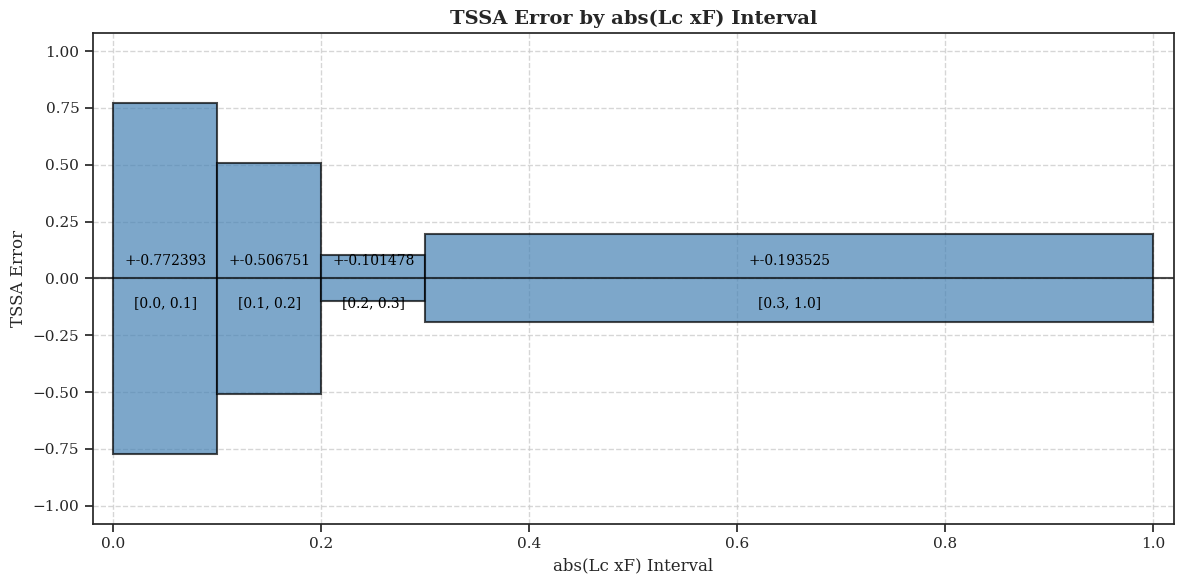

In [10]:
x_label = 'abs(Lc xF)'

tssa_error_plot(
    gaps=gaps,
    tssa_errors_list=tssa_errors_list,
    x_label=x_label
)

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/TSSA_uncertainty_ML_xF.pdf')
plt.show()